# Import

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


file = "https://raw.githubusercontent.com/ekapolc/Pattern_2026/main/HW/HW2/hr-employee-attrition-with-null.csv"
df = pd.read_csv(file)

# Inspect Data

In [3]:
print(df.head())

   Unnamed: 0   Age Attrition     BusinessTravel  DailyRate  \
0           0  41.0       Yes      Travel_Rarely        NaN   
1           1   NaN        No                NaN      279.0   
2           2  37.0       Yes                NaN     1373.0   
3           3   NaN        No  Travel_Frequently     1392.0   
4           4  27.0        No      Travel_Rarely      591.0   

               Department  DistanceFromHome  Education EducationField  \
0                     NaN               1.0        NaN  Life Sciences   
1  Research & Development               NaN        NaN  Life Sciences   
2                     NaN               2.0        2.0            NaN   
3  Research & Development               3.0        4.0  Life Sciences   
4  Research & Development               2.0        1.0        Medical   

   EmployeeCount  ...  RelationshipSatisfaction  StandardHours  \
0            1.0  ...                       1.0           80.0   
1            1.0  ...                       4.0   

# Clean Data

In [4]:
df.loc[df["Attrition"] == "no", "Attrition"] = 0.0
df.loc[df["Attrition"] == "yes", "Attrition"] = 1.0
string_categorical_col = ['Department', 'Attrition', 'BusinessTravel', 'EducationField', 'Gender', 'JobRole',
                              'MaritalStatus', 'Over18', 'OverTime']


for col in df.columns:
    if df[col].dtype == np.float64:
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

    if col in string_categorical_col:
        df[col] = pd.Categorical(df[col]).codes

df = df.loc[:, ~df.columns.isin(['EmployeeNumber', 'Unnamed: 0', 'EmployeeCount', 'StandardHours', 'Over18'])]

In [5]:
test_set = df.groupby('Attrition').sample(frac=0.1, random_state=42)
train_set = df.drop(test_set.index)

# Histrogram Discretization

### T4 Observe the histogram for Age, MonthlyIncome and DistanceFromHome.How many bins have zero counts? Do you think this is a good discretization? Why?

In [6]:
def display_histogram(df=train_set, col_name= "Age", n_bin = 40):
   dsp = df[col_name].dropna()
   counts, bins, patches = plt.hist(dsp, n_bin)
   print(f"Zero bins: {sum(counts == 0)}")
   plt.show()

Zero bins: 0


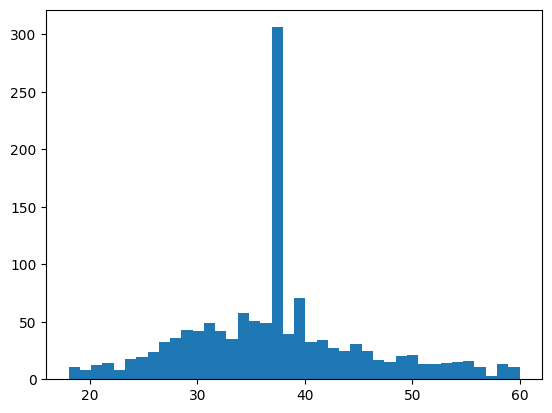

In [7]:
# Histogram for age and zero cout for Age
display_histogram(df=train_set, col_name= "Age", n_bin = 40)

Zero bins: 0


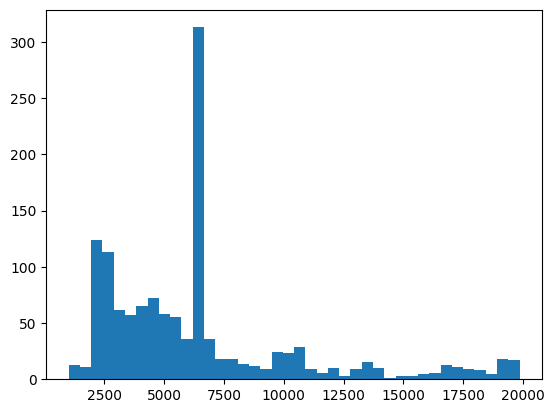

In [8]:
# Histogram for MonthlyIncome and zero cout for MonthlyIncome
display_histogram(col_name= "MonthlyIncome")

Zero bins: 11


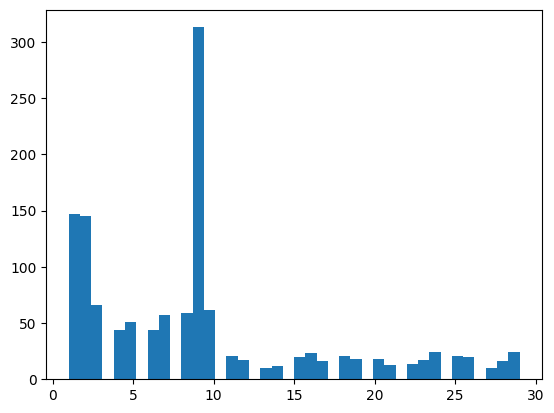

In [9]:
# Histogram for DistanceFromHome and zero cout for DistanceFromHome
display_histogram(col_name= "DistanceFromHome")

From above figure, we can see that 40 n_bins is suitable for age and monthly income as it has 0 zero bins but not that great in distance from home as it has 11 zero bins

### T5 Can we use a Gaussian to estimate this histogram? Why? What about a Gaussian Mixture Model (GMM)?

For a standard Gaussian model is only slightly suitable for Age as it is slighly skew and conbtain a sharp spike in the middle. Moreover, Monthly income and Distance from home is unsuitable for standard Gaussian as it is heavily skew and has a jagged pattern.

Switching to GMM would be suitable for all histrogram as it solve the multiple peak (jagged pattern), approximate the skewness of the histogram, and capture the strong peak of the histrogram.

### T6. Now plot the histogram according to the method described above (with10, 40, and 100 bins) and show 3 plots each for Age, MonthlyIncome, and DistanceFromHome. Which bin size is most sensible for each features? Why?

In [10]:
def display_histogram_2(df=train_set, col_name="Age", n_bin=10):
   dsp = df[col_name].dropna()
    
   bin_edges = np.histogram_bin_edges(dsp, n_bin)
   full_bins = np.concatenate(([-np.inf], bin_edges[1:-1], [np.inf]))
    
   indices = np.digitize(dsp, bin_edges[1:-1])
   counts = np.bincount(indices, minlength=len(full_bins)-1)
    
   print(f"Zero bins: {np.sum(counts == 0)}")
   plt.hist(dsp, bins=bin_edges)
   plt.show()
   
   return counts, full_bins

n_bin = 10
Zero bins: 0


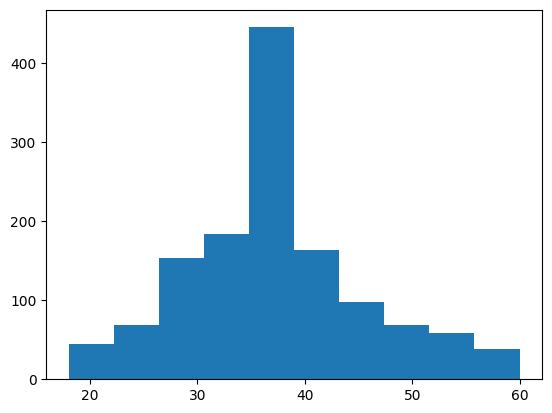

n_bin = 40
Zero bins: 0


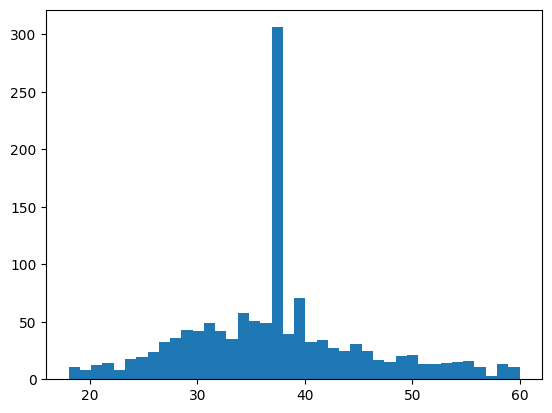

n_bin = 100
Zero bins: 57


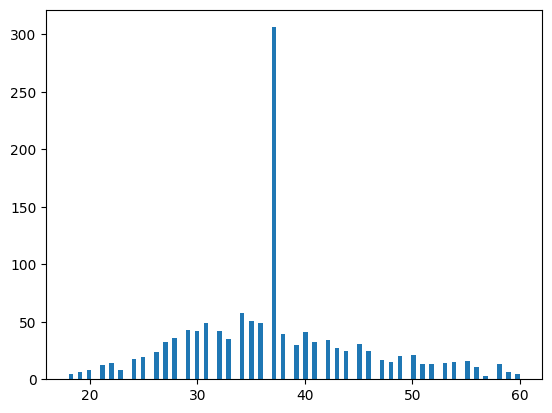

In [11]:
# Histogram for age and zero cout for Age
for n in [10, 40, 100]:
   print(f'n_bin = {n}')
   display_histogram_2(df=train_set, col_name= "Age", n_bin = n)

n_bin = 10
Zero bins: 0


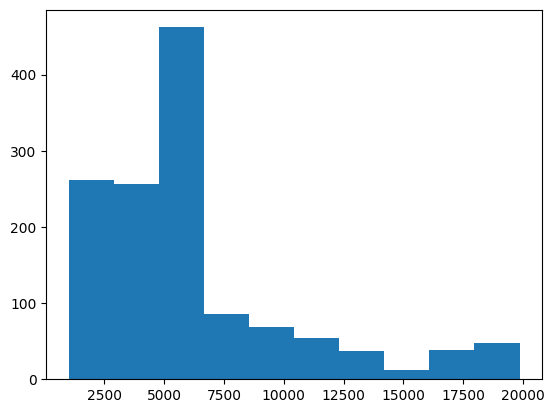

n_bin = 40
Zero bins: 0


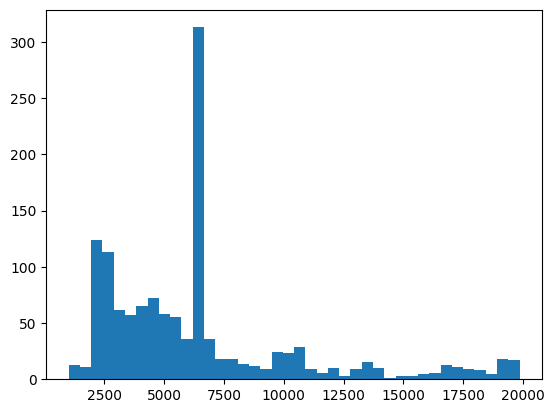

n_bin = 100
Zero bins: 5


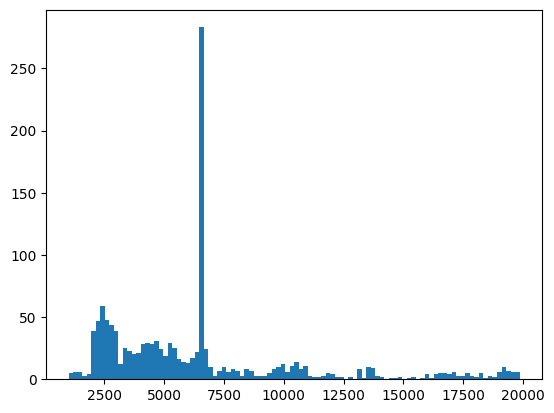

In [12]:
# Histogram for MonthlyIncome and zero cout for MonthlyIncome
for n in [10, 40, 100]:
   print(f'n_bin = {n}')
   display_histogram_2(col_name= "MonthlyIncome", n_bin = n)


n_bin = 10
Zero bins: 0


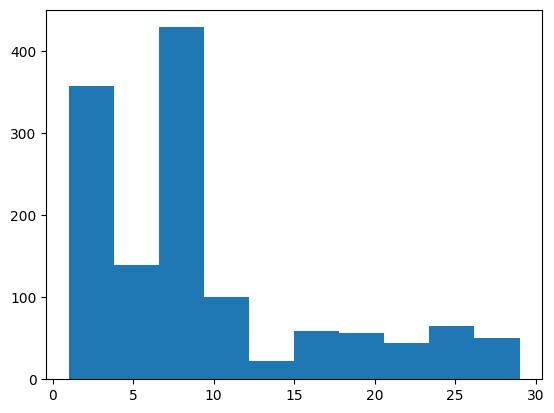

n_bin = 40
Zero bins: 11


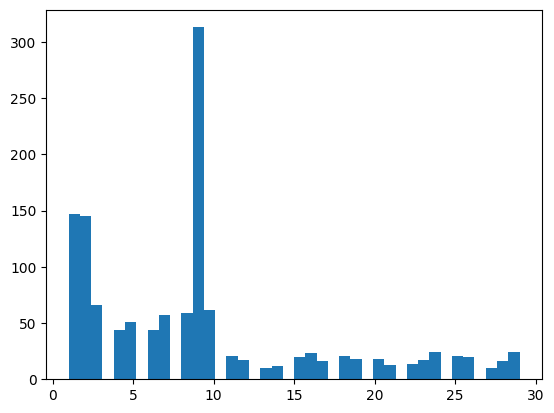

n_bin = 100
Zero bins: 70


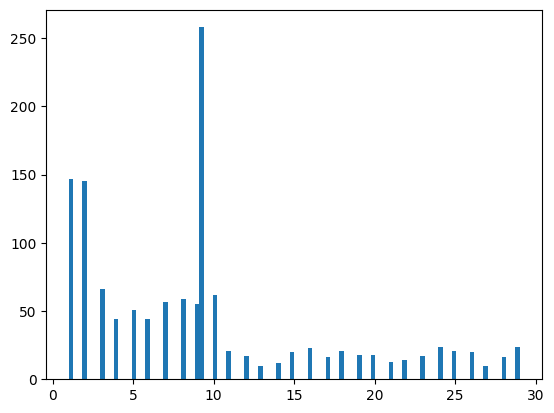

In [13]:
# Histogram for DistanceFromHome and zero cout for DistanceFromHome
for n in [10, 40, 100]:
   print(f'n_bin = {n}')
   display_histogram_2(col_name= "DistanceFromHome", n_bin = n)

From the display above, the suitable n_bin of Age is 10 or 40 as it can clearly show the distribution with 0 zero bins. Monthly income might be suitable at 40 n_bins as it highlight the distribution and Distance from home is suitable for is 10 n_bins as it show 0 zero bins and is enough to show the underlying distribution. 

### T7. For the rest of the features, which one should be discretized in order to be modeled by histograms? What are the criteria for choosing whether we should discretize a feature or not? Answer this and discretize those features into 10 bins each. In other words, figure out the bin edge for each feature, then use digitize() to convert the features to discrete values

We should discretize all non-caterical columns with enough number of columns. 
We also should use the np.digitize version for real modelling usage as it can process the outlier with better range controlling.

Current columns is "DailyRate"
Zero bins: 0


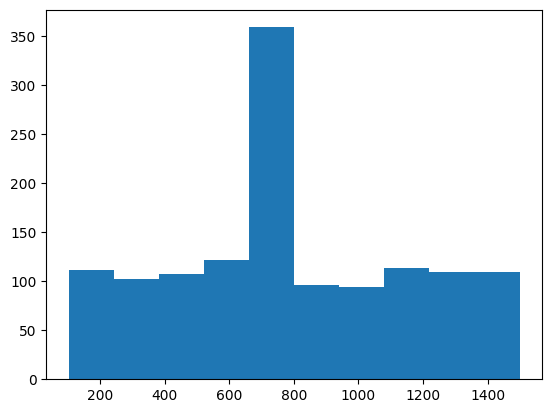

Current columns is "HourlyRate"
Zero bins: 0


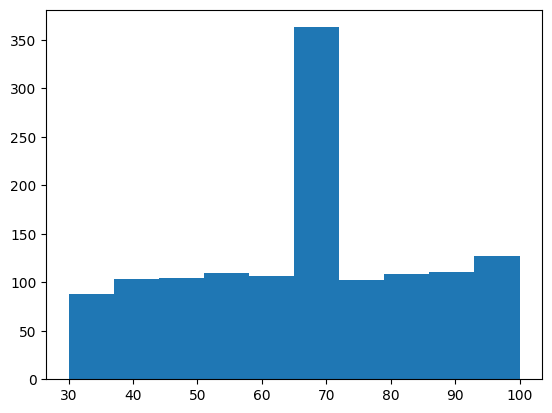

Current columns is "MonthlyRate"
Zero bins: 0


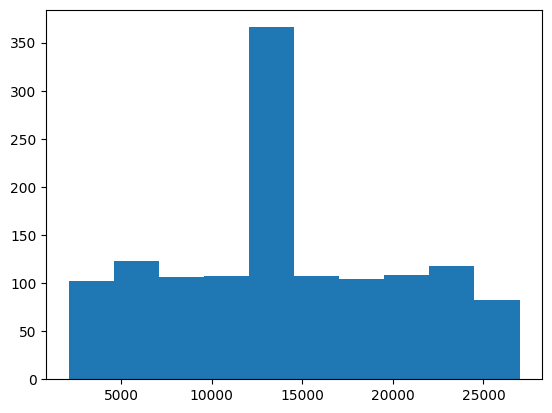

Current columns is "NumCompaniesWorked"
Zero bins: 0


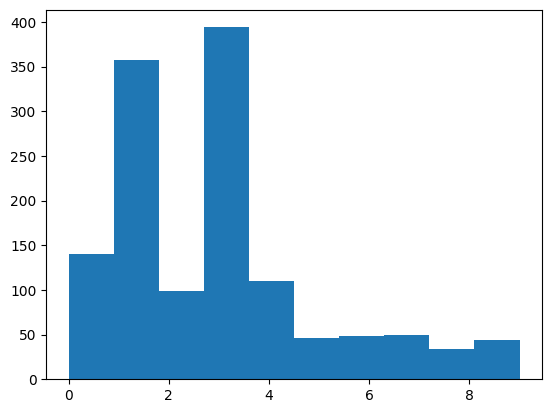

Current columns is "PercentSalaryHike"
Zero bins: 0


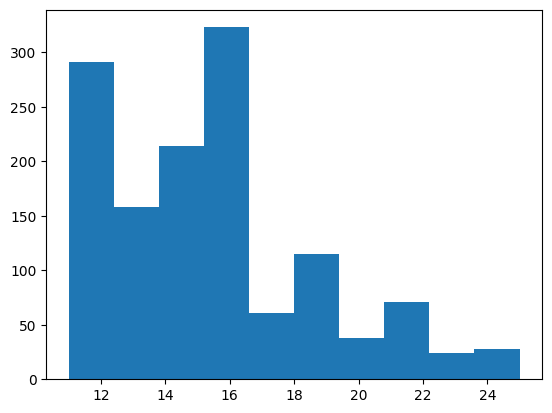

Current columns is "TotalWorkingYears"
Zero bins: 0


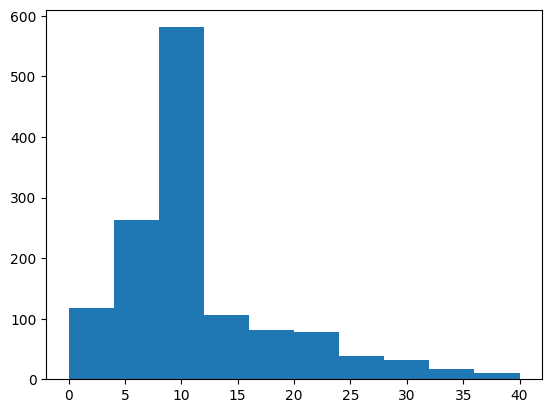

Current columns is "YearsAtCompany"
Zero bins: 0


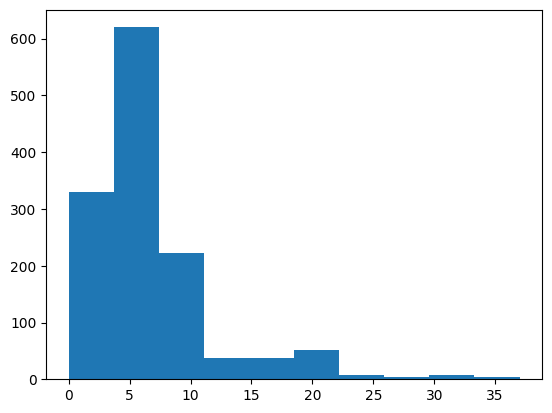

Current columns is "YearsInCurrentRole"
Zero bins: 0


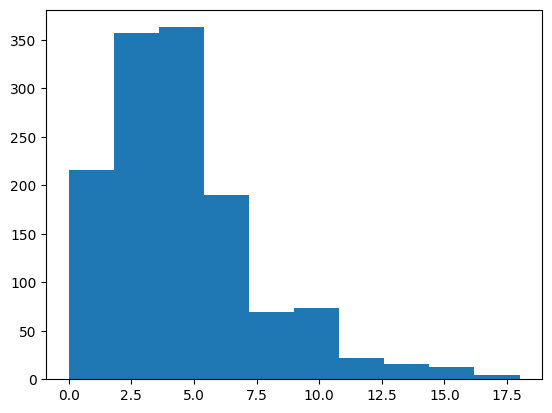

Current columns is "YearsSinceLastPromotion"
Zero bins: 0


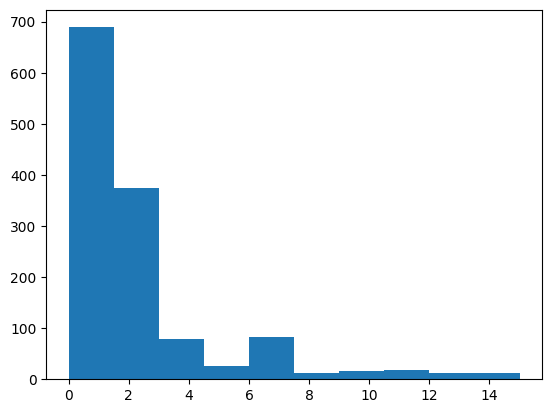

Current columns is "YearsWithCurrManager"
Zero bins: 0


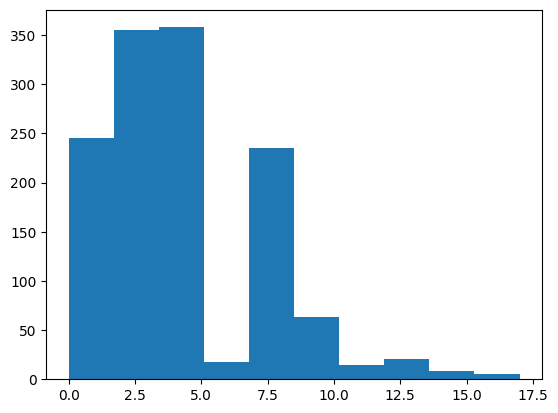

In [14]:
cols = df.columns.to_list()
cols.remove('Attrition')
cols.remove('Age')
cols.remove('MonthlyIncome')
cols.remove('DistanceFromHome')

for col in cols:
   if len(train_set[col].unique()) < 10:
      continue
   print(f'Current columns is "{col}"')
   display_histogram_2(col_name= col, n_bin = 10)

### T8. What kind of distribution should we use to model histograms? (Answer a distribution name) What is the MLE for this likelihood distribution? (Describe how to do the MLE). Plot the likelihood distributions of MonthlyIncome, JobRole, HourlyRate, and MaritalStatus for different Attrition values.

The Multinomial Distribition or Categorical Distribution will work as we arer working with discrete data such as histogram

MonthlyIncome


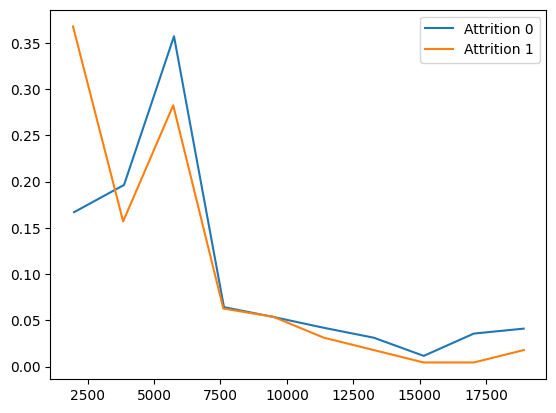

JobRole


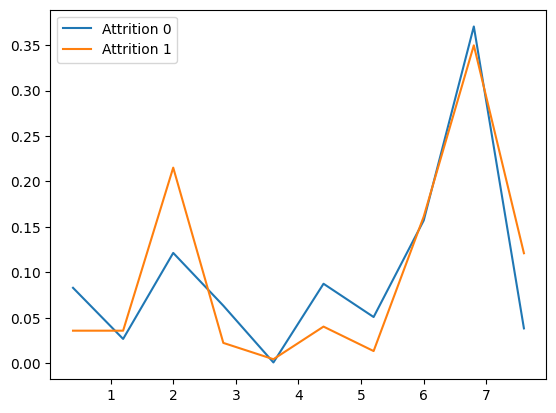

HourlyRate


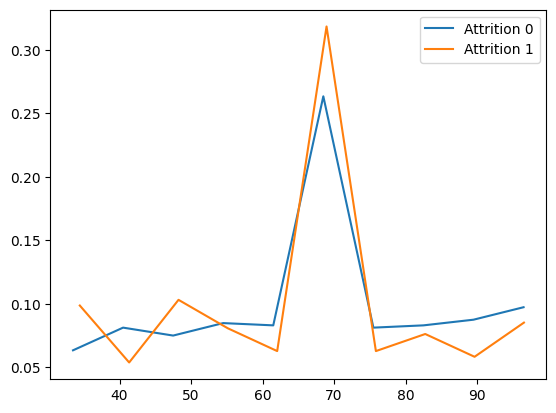

MaritalStatus


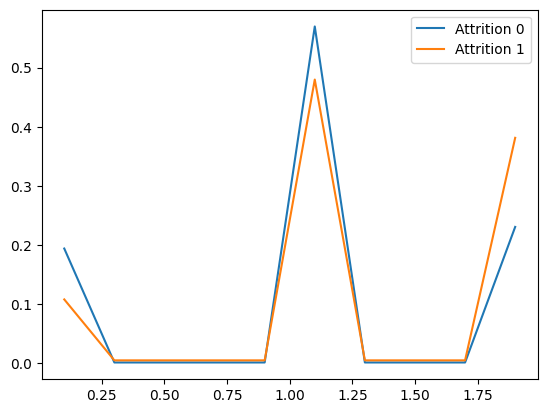

In [16]:
def plot_mle(df, col, n_bin=10):
   for val in [0, 1]:
      dsp = df[df['Attrition'] == val][col].dropna()
        
      counts, edges = np.histogram(dsp, bins=n_bin)
      mle = (counts + 1) / (counts.sum() + n_bin)
        
      bin_centers = (edges[:-1] + edges[1:]) / 2

      plt.plot(bin_centers, mle, label=f'Attrition {val}')
    
   plt.legend()
   plt.show()

cols = ['MonthlyIncome', 'JobRole', 'HourlyRate', 'MaritalStatus']
for col in cols:
   print(col)
   plot_mle(train_set, col)

The process of MLE calculation for given distribution is just a count of sample in that bin / total sample. Additionally to avoid zero bin, we can just +1 

### T9. What is the prior distribution of the two classes?

In [17]:
leave_count = df['Attrition'].value_counts()[1]
total = len(df)
leave_prob = leave_count/total

print("prob of leave", leave_prob)
print("prob of stay", 1-leave_prob)

prob of leave 0.16122448979591836
prob of stay 0.8387755102040817


### T10. If we use the current Naive Bayes with our current Maximum Likelihood Estimates, we will find that some P(xi|attrition) will be zero and will result in the entire product term to be zero. Propose a method to fix this problem.

As mention in T8, We can use laplace smoothing to add 1 counts in every bin so that all zero bin will become 1

### T11. Implement your Naive Bayes classifier. Use the learned distributions to classify the test set. Don’t forget to allow your classifier to handle missing values in the test set. Report the overall Accuracy. Then, report the Precision, Recall, and F score for detecting attrition. See Lecture 1 for the definitions of each metric.

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_mle_probs(df, col, n_bin=10):
   result = {}
   for outcome in [0, 1]:
      subset = df[df['Attrition'] == outcome][col]
      counts, edges = np.histogram(subset, bins=n_bin)
      probs = (counts + 1) / (counts.sum() + n_bin)
      result[outcome] = (probs, edges)
   return result

features = [c for c in train_set.columns if c != 'Attrition']
model_stats = {feature: get_mle_probs(train_set, feature) for feature in features}
priors = train_set['Attrition'].value_counts(normalize=True).to_dict()

def predict(row):
    log_probs = {0: np.log(priors[0]), 1: np.log(priors[1])}
    for feature in features:
        val = row[feature]
        if pd.isna(val): continue
        for outcome in [0, 1]:
            probs, edges = model_stats[feature][outcome]
            bin_idx = np.digitize(val, edges[1:-1])
            log_probs[outcome] += np.log(probs[bin_idx])
    return 1 if log_probs[1] > log_probs[0] else 0

y_true = test_set['Attrition'].values
y_pred = test_set.apply(predict, axis=1).values

print(f"Accuracy: {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred)}")
print(f"Recall: {recall_score(y_true, y_pred)}")
print(f"F1 Score: {f1_score(y_true, y_pred)}")

Accuracy: 0.8503401360544217
Precision: 0.5555555555555556
Recall: 0.4166666666666667
F1 Score: 0.47619047619047616


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_mle_probs(df, col, n_bin=10):
   result = {}
   for outcome in [0, 1]:
      subset = df[df['Attrition'] == outcome][col]
      counts, edges = np.histogram(subset, bins=n_bin)
      probs = (counts + 1) / (counts.sum() + n_bin)
      result[outcome] = (probs, edges)
   return result

features = [c for c in train_set.columns if c != 'Attrition']
model_stats = {feature: get_mle_probs(train_set, feature) for feature in features}
priors = train_set['Attrition'].value_counts(normalize=True).to_dict()

def predict(row):
    log_probs = {0: np.log(priors[0]), 1: np.log(priors[1])}
    for feature in features:
        val = row[feature]
        if pd.isna(val): continue
        for outcome in [0, 1]:
            probs, edges = model_stats[feature][outcome]
            bin_idx = np.digitize(val, edges[1:-1])
            log_probs[outcome] += np.log(probs[bin_idx])
    return 1 if log_probs[1] > log_probs[0] else 0

y_true = test_set['Attrition'].values
y_pred = test_set.apply(predict, axis=1).values

print(f"Accuracy: {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred)}")
print(f"Recall: {recall_score(y_true, y_pred)}")
print(f"F1 Score: {f1_score(y_true, y_pred)}")

Accuracy: 0.8503401360544217
Precision: 0.5555555555555556
Recall: 0.4166666666666667
F1 Score: 0.47619047619047616


### T12. Use the learned distributions to classify the test set. Report the results using the same metric as the previous question.

In [20]:
from scipy.stats import norm

continuous_features = ['Age', 'MonthlyIncome', 'DistanceFromHome', 'HourlyRate']
categorical_features = [c for c in train_set.columns if c not in continuous_features + ['Attrition']]

gauss_stats = {}
for feature in continuous_features:
    gauss_stats[feature] = {
        outcome: (train_set[train_set['Attrition'] == outcome][feature].mean(),
                  train_set[train_set['Attrition'] == outcome][feature].std())
        for outcome in [0, 1]
    }

model_stats = {feat: get_mle_probs(train_set, feat) for feat in categorical_features}
priors = train_set['Attrition'].value_counts(normalize=True).to_dict()

def predict_gaussian(row):
   log_probs = {0: np.log(priors[0]), 1: np.log(priors[1])}
    
   for feature in train_set.columns:
      if feature == 'Attrition' or pd.isna(row[feature]): continue
        
      for outcome in [0, 1]:
         if feature in continuous_features:
            mean, std = gauss_stats[feature][outcome]
            prob = norm(mean, std).pdf(row[feature])
            log_probs[outcome] += np.log(prob if prob > 0 else 1e-9)
         else:
            probs, edges = model_stats[feature][outcome]
            bin_idx = np.digitize(row[feature], edges[1:-1])
            log_probs[outcome] += np.log(probs[bin_idx])
                
   return 1 if log_probs[1] > log_probs[0] else 0

y_true = test_set['Attrition'].values
y_pred = test_set.apply(predict_gaussian, axis=1).values

print(f"Accuracy: {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred)}")
print(f"Recall: {recall_score(y_true, y_pred)}")
print(f"F1 Score: {f1_score(y_true, y_pred)}")

Accuracy: 0.8503401360544217
Precision: 0.55
Recall: 0.4583333333333333
F1 Score: 0.5


### T13. The random choice baseline is the accuracy if you make a random guessfor each test sample. Give random guess (50% leaving, and 50% staying) to the test samples. Report the overall Accuracy. Then, report the Precision, Recall, and F score for attrition prediction using the random choice baseline.


In [21]:
def predict_baseline(row):
   return np.random.choice([0.0, 1.0])

np.random.seed(42)
y_true = test_set['Attrition'].values
y_pred = test_set.apply(predict_baseline, axis=1).values

print(f"Accuracy: {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred)}")
print(f"Recall: {recall_score(y_true, y_pred)}")
print(f"F1 Score: {f1_score(y_true, y_pred)}")

Accuracy: 0.40816326530612246
Precision: 0.1111111111111111
Recall: 0.375
F1 Score: 0.17142857142857143


### T14. The majority rule is the accuracy if you use the most frequent class from the training set as the classification decision. Report the overall Accuracy. Then, report the Precision, Recall, and F score for attrition prediction using the majority rule baseline.


In [22]:
majority_class = train_set['Attrition'].mode()[0]
def predict_majority(row):
   return majority_class


y_true = test_set['Attrition'].values
y_pred = test_set.apply(predict_majority, axis=1).values

print(f"Accuracy: {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred)}")
print(f"Recall: {recall_score(y_true, y_pred)}")
print(f"F1 Score: {f1_score(y_true, y_pred)}")

Accuracy: 0.8367346938775511
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


d:\python129\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### T15. Compare the two baselines with your Naive Bayes classifier.

### My naive bayes (multinomial distribution)
Accuracy: 0.8503401360544217
Precision: 0.5555555555555556
Recall: 0.4166666666666667
F1 Score: 0.47619047619047616

### Random (state 42)
Accuracy: 0.40816326530612246
Precision: 0.1111111111111111
Recall: 0.375
F1 Score: 0.17142857142857143

### Majority (all stay)
Accuracy: 0.8367346938775511
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

### Analysis
First off, we can ignore majority as it only predict 'stay' which lead to accuracy be equal to the % of people stay in train set (we statify so both class distribution is the same) and else is zero due to the 100% missrate when predicting people who leaves

For naive bayes and random, we can see that naive bayes has better result on every field which reflected that our training prove to be benficial to model performance, at least it is better than random guessing

Additionally for naive bayes with guassian distribution, the result is almost the same as our multinomial with slightly more recall and F1

### T16. Use the following threshold values 't = np.arange(-5,5,0.05)' find the best accuracy, and F score (and the corresponding thresholds)

Im using my multinomial distribution predict with threshold

In [23]:
def get_mle_probs(df, col, n_bin=10):
   result = {}
   for outcome in [0, 1]:
      subset = df[df['Attrition'] == outcome][col]
      counts, edges = np.histogram(subset, bins=n_bin)
      probs = (counts + 1) / (counts.sum() + n_bin)
      result[outcome] = (probs, edges)
   return result

features = [c for c in train_set.columns if c != 'Attrition']
model_stats = {feature: get_mle_probs(train_set, feature) for feature in features}
priors = train_set['Attrition'].value_counts(normalize=True).to_dict()

def predict_with_threshold(row, threshold):
    log_probs = {0: np.log(priors[0]), 1: np.log(priors[1])}
    for feature in features:
        val = row[feature]
        if pd.isna(val): continue
        for outcome in [0, 1]:
            probs, edges = model_stats[feature][outcome]
            bin_idx = np.digitize(val, edges[1:-1])
            log_probs[outcome] += np.log(probs[bin_idx])
    return 1 if log_probs[1] - log_probs[0] > threshold else 0

In [24]:
thresholds = np.arange(-5, 5, 0.05)
best_acc, best_f1 = 0, 0
best_t_acc, best_t_f1 = 0, 0

for t in thresholds:
    preds = test_set.apply(lambda r: predict_with_threshold(r, threshold=t), axis=1)
    acc = accuracy_score(y_true, preds)
    f1 = f1_score(y_true, preds)
    
    if acc > best_acc: best_acc, best_t_acc = acc, t
    if f1 > best_f1: best_f1, best_t_f1 = f1, t

print(f"\nBest threshold Accuracy: {best_acc} at threshold {best_t_acc}")
print(f"Best threshold F1: {best_f1} at threshold {best_t_f1}")


Best threshold Accuracy: 0.8707482993197279 at threshold 1.0999999999999783
Best threshold F1: 0.6206896551724138 at threshold -1.4000000000000128


### T17. Plot the RoC of your classifier.

Using same predict_with_threshold but calculate ROC and plot

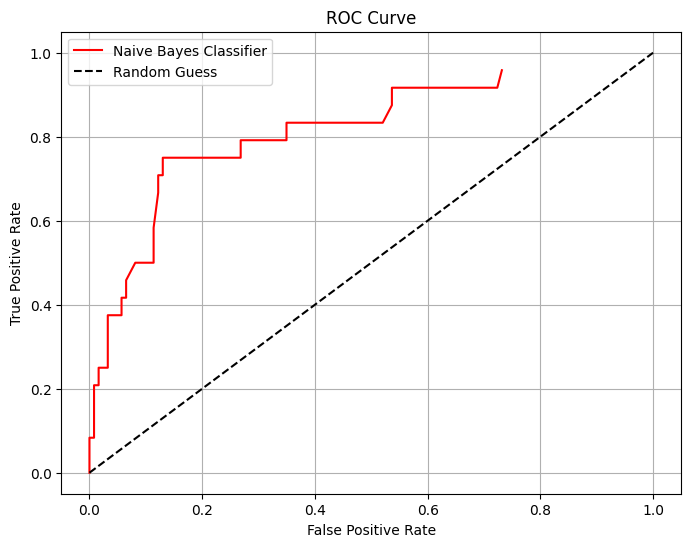

In [25]:
from sklearn.metrics import confusion_matrix

thresholds = np.arange(-5, 5, 0.05)
metrics = []

for t in thresholds:
    preds = test_set.apply(lambda r: predict_with_threshold(r, threshold=t), axis=1)
    
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    metrics.append({'t': t, 'acc': acc, 'f1': f1, 'tpr': tpr, 'fpr': fpr})

fpr_vals = [m['fpr'] for m in metrics]
tpr_vals = [m['tpr'] for m in metrics]

plt.figure(figsize=(8, 6))
plt.plot(fpr_vals, tpr_vals, label='Naive Bayes Classifier', color='red')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

### T18. Change the number of discretization bins to 5. What happens to the RoC curve? Which discretization is better? 

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_mle_probs(df, col, n_bin=5):
   result = {}
   for outcome in [0, 1]:
      subset = df[df['Attrition'] == outcome][col]
      counts, edges = np.histogram(subset, bins=n_bin)
      probs = (counts + 1) / (counts.sum() + n_bin)
      result[outcome] = (probs, edges)
   return result

features = [c for c in train_set.columns if c != 'Attrition']
model_bin5_stats = {feature: get_mle_probs(train_set, feature) for feature in features}
priors = train_set['Attrition'].value_counts(normalize=True).to_dict()

def predict_with_threshold_bin5(row, threshold):
    log_probs = {0: np.log(priors[0]), 1: np.log(priors[1])}
    for feature in features:
        val = row[feature]
        if pd.isna(val): continue
        for outcome in [0, 1]:
            probs, edges = model_bin5_stats[feature][outcome]
            bin_idx = np.digitize(val, edges[1:-1])
            log_probs[outcome] += np.log(probs[bin_idx])
    return 1 if log_probs[1] - log_probs[0] > threshold else 0


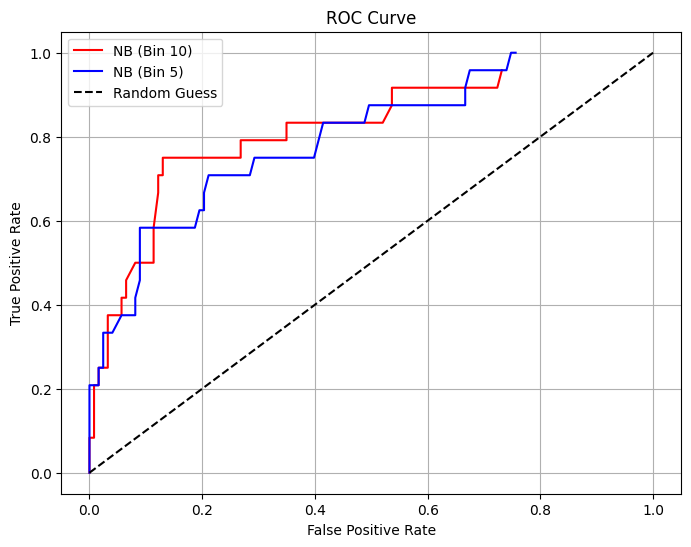

In [27]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

thresholds = np.arange(-5, 5, 0.05)
metrics_10 = []
metrics_5 = []

for t in thresholds:
    preds10 = test_set.apply(lambda r: predict_with_threshold(r, threshold=t), axis=1)
    tn10, fp10, fn10, tp10 = confusion_matrix(y_true, preds10).ravel()
    tpr10 = tp10 / (tp10 + fn10) if (tp10 + fn10) > 0 else 0
    fpr10 = fp10 / (fp10 + tn10) if (fp10 + tn10) > 0 else 0
    metrics_10.append({'fpr': fpr10, 'tpr': tpr10})

    preds5 = test_set.apply(lambda r: predict_with_threshold_bin5(r, threshold=t), axis=1)
    tn5, fp5, fn5, tp5 = confusion_matrix(y_true, preds5).ravel()
    tpr5 = tp5 / (tp5 + fn5) if (tp5 + fn5) > 0 else 0
    fpr5 = fp5 / (fp5 + tn5) if (fp5 + tn5) > 0 else 0
    metrics_5.append({'fpr': fpr5, 'tpr': tpr5})

fpr10_vals = [m['fpr'] for m in metrics_10]
tpr10_vals = [m['tpr'] for m in metrics_10]
fpr5_vals = [m['fpr'] for m in metrics_5]
tpr5_vals = [m['tpr'] for m in metrics_5]

plt.figure(figsize=(8, 6))
plt.plot(fpr10_vals, tpr10_vals, label='NB (Bin 10)', color='red')
plt.plot(fpr5_vals, tpr5_vals, label='NB (Bin 5)', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# Threshold tuning for bin5

thresholds = np.arange(-5, 5, 0.05)
best_acc, best_f1 = 0, 0
best_t_acc, best_t_f1 = 0, 0

for t in thresholds:
    preds = test_set.apply(lambda r: predict_with_threshold_bin5(r, threshold=t), axis=1)
    acc = accuracy_score(y_true, preds)
    f1 = f1_score(y_true, preds)
    
    if acc > best_acc: best_acc, best_t_acc = acc, t
    if f1 > best_f1: best_f1, best_t_f1 = f1, t

print(f"\nBest threshold Accuracy: {best_acc} at threshold {best_t_acc}")
print(f"Best threshold F1: {best_f1} at threshold {best_t_f1}")


Best threshold Accuracy: 0.8707482993197279 at threshold -0.3500000000000165
Best threshold F1: 0.5714285714285714 at threshold -1.050000000000014


To compare we also tune to find best threshold for bin5 NB the result show 
### Bin 5
Best threshold Accuracy: 0.8707482993197279 at threshold -0.3500000000000165
Best T16 F1: 0.5714285714285714 at threshold -1.050000000000014

### Bin 10
Best threshold Accuracy: 0.8707482993197279 at threshold 1.0999999999999783
Best threshold F1: 0.6206896551724138 at threshold -1.4000000000000128


The accuracy is equal but Bin 10 seem to show better F1 score so it is reasonable to say that Bin 10 is better

### T19. Submit your code (.py or .ipynb) on mycourseville.

I submit all this as .pdf but if you want file, please download from this collab ...

### OT4. Shuffle the database, and create new test and train sets. Redo the entire training and evaluation process 10 times (each time with a new training and test set). Calculate the mean and variance of the accuracy rate

In [29]:
accuracies = []

for i in range(10):
   shuffled_df = df.sample(frac=1, random_state=i)
   test_set = shuffled_df.groupby('Attrition').sample(frac=0.1)
   train_set = shuffled_df.drop(test_set.index)

   features = [c for c in train_set.columns if c != 'Attrition']
   model_stats = {feature: get_mle_probs(train_set, feature) for feature in features}
   priors = train_set['Attrition'].value_counts(normalize=True).to_dict()

   y_true = test_set['Attrition'].values
   y_pred = test_set.apply(predict, axis=1).values
    
   accuracies.append(accuracy_score(y_true, y_pred))

print(f"Mean Accuracy: {np.mean(accuracies)}")
print(f"Variance of Accuracy: {np.var(accuracies)}")

Mean Accuracy: 0.8503401360544217
Variance of Accuracy: 0.0002961728909250767
